#Experiment 10. Analyze the loss functions used in GAN training (e.g., adversarial loss, feature matching loss).


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 699kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.02MB/s]


Epoch 1/15 | Adv: 1.2902 | FM: 2.5328 | W: -0.5170
Epoch 2/15 | Adv: 1.2486 | FM: 4.2448 | W: -0.3619
Epoch 3/15 | Adv: 0.9464 | FM: 2.4200 | W: -0.1880
Epoch 4/15 | Adv: 1.0549 | FM: 3.4531 | W: -0.2944
Epoch 5/15 | Adv: 1.0751 | FM: 2.7472 | W: -0.2934
Epoch 6/15 | Adv: 0.7313 | FM: 1.0327 | W: -0.0845
Epoch 7/15 | Adv: 1.4805 | FM: 4.2463 | W: -0.4849
Epoch 8/15 | Adv: 1.1705 | FM: 2.6094 | W: -0.3761
Epoch 9/15 | Adv: 1.1849 | FM: 1.8246 | W: -0.2982
Epoch 10/15 | Adv: 1.1525 | FM: 2.2776 | W: -0.3553
Epoch 11/15 | Adv: 1.6622 | FM: 2.3658 | W: -0.5530
Epoch 12/15 | Adv: 0.9355 | FM: 2.5420 | W: -0.2191
Epoch 13/15 | Adv: 1.1582 | FM: 3.9001 | W: -0.1802
Epoch 14/15 | Adv: 1.8486 | FM: 3.4193 | W: -0.5955
Epoch 15/15 | Adv: 3.0837 | FM: 6.6562 | W: -0.8475


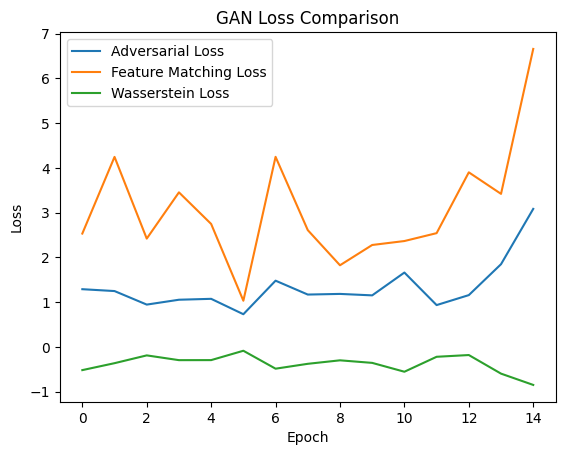

In [2]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

#  Step 1: Load Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

loader = DataLoader(
    datasets.MNIST('./data', train=True, download=True, transform=transform),
    batch_size=64,
    shuffle=True
)

#  Step 2: Hyperparameters
latent_dim = 50
epochs = 15

#  Step 3: Generator
G = nn.Sequential(
    nn.Linear(latent_dim, 128),
    nn.ReLU(),
    nn.Linear(128, 784),
    nn.Tanh()
)

#  Step 4: Discriminator
D = nn.Sequential(
    nn.Linear(784, 128),
    nn.LeakyReLU(0.2),
    nn.Linear(128, 1),
    nn.Sigmoid()
)

#  Step 5: Optimizers
opt_G = torch.optim.Adam(G.parameters(), lr=0.0002)
opt_D = torch.optim.Adam(D.parameters(), lr=0.0002)

bce = nn.BCELoss()
mse = nn.MSELoss()

#  Step 6: Tracking
adv_losses = []
fm_losses = []
w_losses = []

#  Step 7: Training
for epoch in range(epochs):
    for real, _ in loader:
        real = real.view(-1, 784)
        bs = real.size(0)

        real_labels = torch.ones(bs, 1)
        fake_labels = torch.zeros(bs, 1)

        #  Generate Fake
        z = torch.randn(bs, latent_dim)
        fake = G(z)

        # Train Discriminator
        loss_D = bce(D(real), real_labels) + bce(D(fake.detach()), fake_labels)

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # Train Generator
        fake = G(z)
        adv_loss = bce(D(fake), real_labels)

        opt_G.zero_grad()
        adv_loss.backward()
        opt_G.step()

        # Feature Matching Loss
        real_feat = D[0](real)     # first layer features
        fake_feat = D[0](fake)
        fm_loss = mse(fake_feat.mean(0), real_feat.mean(0).detach())

        #  Wasserstein Loss
        w_loss = -(D(real).mean() - D(fake).mean())

    # Save per epoch
    adv_losses.append(adv_loss.item())
    fm_losses.append(fm_loss.item())
    w_losses.append(w_loss.item())

    print(f"Epoch {epoch+1}/{epochs} | Adv: {adv_loss.item():.4f} | FM: {fm_loss.item():.4f} | W: {w_loss.item():.4f}")

# Step 8: Plot Losses
plt.plot(adv_losses, label="Adversarial Loss")
plt.plot(fm_losses, label="Feature Matching Loss")
plt.plot(w_losses, label="Wasserstein Loss")

plt.title("GAN Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()